In [1]:
import os
import re
import numpy as np
import pandas as pd
import json
import time
import subprocess
import itertools

from math import pow,factorial,log,exp
from matplotlib import pyplot as plt, colors
from options_utility import parse_args, get_test_options, extract_arg_values
from workflow_parser import get_workflow, WorkflowIterator
from test_utility import generate_test
from docker_utility import SERVICES, create_containers, stop_containers

In [ ]:
def get_s(l: list) -> str:
    """
    Returns a string from a list of strings
    """
    return "[" + ','.join([str(i) for i in l]) + "]"

def PowerFact(b,e):
    """
    Returns b^e / e! used everywhere else in the model
    
    Parameters:
        b (int): base
        e (int): exponent
    """
    return pow(b,e) / factorial(e)

def erlangC(m,p):
    """
    Returns the probability a call waits.

    Parameters:
        m   (int): agent count
        p (float): lambda over (m times mu)
    """
    u = m * p
    suma = 0
    for k in range(0,m):
        suma += PowerFact(u,k)
    erlang = PowerFact(u,m) / ((PowerFact(u,m)) + (1-p)*suma)
    return erlang
    
def parse_jaeger_traces(file_path) -> tuple[pd.DataFrame, float, float]:
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    processed_traces = []
    overall_min_start_time_us = float('inf')
    overall_max_end_time_us = 0
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return [], 0, 0
    except json.JSONDecodeError:
        print(f"Error: The file '{file_path}' is not a valid JSON file.")
        return [], 0, 0

    if 'data' not in data or not isinstance(data['data'], list):
        print("Error: JSON file does not have the expected Jaeger format (missing 'data' array).")
        return [], 0, 0

    for trace in data['data']:
        user_id = None
        min_start_time = float('inf')
        max_end_time = 0

        if 'spans' not in trace or not trace['spans']:
            continue

        # Determine the absolute start and end time for this trace
        for span in trace['spans']:
            start_time = span.get('startTime', 0)
            duration = span.get('duration', 0)
            end_time = start_time + duration
            
            if start_time < min_start_time:
                min_start_time = start_time
            if end_time > max_end_time:
                max_end_time = end_time

        if min_start_time != float('inf'):
            processed_traces.append({
                'user_id': user_id,
                'duration': (max_end_time - min_start_time) // 1000,
                'start_time_us': min_start_time,
                'end_time_us': max_end_time
            })
            # Update overall min and max times
            if min_start_time < overall_min_start_time_us:
                overall_min_start_time_us = min_start_time
            if max_end_time > overall_max_end_time_us:
                overall_max_end_time_us = max_end_time

    return pd.DataFrame(processed_traces), overall_min_start_time_us, overall_max_end_time_us

def parse_metric_traces(file_path):
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    
    df = pd.read_csv(file_path)

    # Filtra solo le righe con la metrica http_req_duration
    durations = df[df["metric_name"] == "http_req_duration"].copy()

    # Calcola tempo di inizio e fine in microsecondi
    durations["start_time_us"] = durations["timestamp"] - durations['metric_value'].astype(int) * 1_000
    durations["end_time_us"] = (durations["timestamp"])

    # normalize by 0
    first = durations["start_time_us"].min()
    durations["start_time_us"] = durations["start_time_us"] - first
    durations["end_time_us"] = durations["end_time_us"] - first 

    # Seleziona colonne utili
    result = durations[["timestamp", "metric_value", "start_time_us", "status", "end_time_us", "url", "scenario", "extra_tags", "metadata"]]

    return pd.DataFrame(result), result["start_time_us"].min(), result["end_time_us"].max()

def calculate_concurrency(traces, start_time_us: int, end_time_us: int, l = 1) -> pd.DataFrame:
    """
    Calculates the number of concurrent users for each second between
    the provided start and end times and returns a DataFrame.

    Returns:
        pd.DataFrame: with columns ['timestamp', 'concurrent_users']
                      where 'timestamp' is in seconds from simulation start.
    """
    timestamps = []
    concurrency_counts = []

    timestep_us = 1_000_000 // l  # 1 second in microsenconds, adjusted by the load factor l

    current_time_us = start_time_us + timestep_us // 2

    while current_time_us <= end_time_us:
        active_users = traces[(traces['start_time_us'] <= current_time_us) & (current_time_us < traces['end_time_us'])]        
        
        timestamps.append((current_time_us - start_time_us) // 1000)  # Convert microseconds to seconds
        concurrency_counts.append(len(active_users))

        current_time_us += timestep_us

    df = pd.DataFrame({
        'timestamp': timestamps,
        'concurrent_users': concurrency_counts
    })

    return df

def find_steady_state_start(diff_series, window=5, epsilon=0.5):
    for i in range(window, len(diff_series)):
        recent = diff_series.iloc[i-window:i].abs()
        if all(recent < epsilon):
            return i - window  # Index where steady state starts
    return None

def load_single_results(num_cores: list, mu: list, concurrent_users: int, iteration: int, path: str = None) -> pd.DataFrame | None:
    folder_path = path
    # df = pd.json_normalize(dict['metrics'])
    df = pd.DataFrame()
    
    test_file = "report.csv"
    file_path = os.path.join(folder_path, test_file)
    spans = []

    if 'jaeger' in test_file:
        with open(file_path) as train_file:
            dict = json.load(train_file)
            spans = []
            for trace in dict['data']:
                for span in trace['spans']:
                    if re.match("GET /", span['operationName']):
                        spans.append(span)
            
            durations = pd.DataFrame([(span['duration'], span['processID']) for span in spans], columns=['duration', 'service'])
            mean_duration = durations.groupby('service')['duration'].mean().reset_index()

            #TODO: Separate by each load
            df = mean_duration
    else:
        df, start_us, end_us = parse_metric_traces(file_path)

    df['iteration'] = iteration

    return df

def load_results(options: dict[str, str]) -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()

    core_combinations = [
        [ {"name": d["name"], "core": c} for d, c in zip(options["NODES"], combo) ]
        for combo in itertools.product(*(d["cores"] for d in options["NODES"]))
    ]

    for c in core_combinations:
        load_combinations = itertools.product(*(d["users"] if "users" in d else d["rate"] for d in options["LOAD"]["loads"]))

        for l in load_combinations:
            for i in range(options["LOAD"]['start'], options["LOAD"]['end']):
                it = WorkflowIterator(options["WORKFLOW"])
                for arg_comb in it:
                    flat_args = extract_arg_values(arg_comb)
                    path = os.path.join(options["RESULT_FOLDER"], "test", f"{get_s([d['core'] for d in c])}", get_s(l), str(get_s(flat_args)), str(i))
                    single_df = load_single_results([d["core"] for d in c], arg_comb, l, i, path)
                    # assign the right mu and cores from the num_core list and mu list
                    # the num cores depends on the index of the node name in the cores 
                    single_df['cores'] = single_df['extra_tags'].apply(lambda x: x.split('=')[1])
                    single_df['cores'] = single_df['cores'].apply(lambda x: next((item["core"] for item in c if item["name"] == x), None))
                    # the load depends on the value of the scenario tag
                    single_df['mu'] = single_df['scenario'].apply(lambda x: l[int(x.split('_')[2])])
                    single_df['service_name'] = single_df['extra_tags'].apply(lambda x: x.split('=')[1])
                    # extract the value of the lambda param
                    def extract_lambda_value(scenario_str: str, service_name: str) -> float | None:
                        scenario_idx = int(scenario_str.split('_')[2])
                        if scenario_idx >= len(flat_args):
                            return None
                        
                        value = flat_args[scenario_idx]
                        workflow = options["WORKFLOW"][scenario_idx]
                        wf_services = workflow.get('services', [])

                        service_idx = next((i for i, svc in enumerate(wf_services) if svc.get('node_name') == service_name), None)
                        if service_idx is None or scenario_idx >= len(flat_args):
                            return (value, workflow['type'])
    
                        value = flat_args[scenario_idx]
                        workflow = workflow['services'][service_idx]
                        
                        # If value is a list, get the element at service_idx
                        if isinstance(value, (list, tuple)):
                            if service_idx >= len(value):
                                return None
                            value = value[service_idx]
                        
                        # Unwrap nested lists/tuples
                        while isinstance(value, (list, tuple)):
                            if len(value) == 0:
                                return None
                            value = value[0]
                        
                        # Return scalar value (int or float)
                        return (value, workflow['type']) if isinstance(value, (int, float)) else None

                    res = single_df.apply(lambda row: extract_lambda_value(row['scenario'], row['service_name']), axis=1)
                    single_df['mu'], single_df['service'] = zip(*res)
                    # df = df.loc[:,~df.columns.str.contains('contains|type')]
                    if single_df is not None:
                        df = pd.concat([df, single_df], ignore_index=True)


    return df.fillna(0)

def is_outlier(s: pd.Series) -> pd.Series:
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    return (s < (Q1 - 1.5 * IQR)) | (s > (Q3 + 1.5 * IQR))


In [103]:
notebook_folder = os.getcwd()
options = get_test_options(os.path.join(notebook_folder, 'base_complex_load', '3_seq'))
print(options)
test_result = load_results(options)
test_result

{'RESULT_FOLDER': '/mnt/s/Projects/qesm/docker-workflows-experimentation/tests/k6/base_complex_load/3_seq', 'TEST_SERVICE': '3_seq', 'TEST_PATH': '/mnt/s/Projects/qesm/docker-workflows-experimentation/tests/k6', 'WORKFLOW': [{'node_name': 'first', 'type': 'sequential', 'services': [{'node_name': 'first', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [50000000]}, {'node_name': 'second', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [25000000]}, {'node_name': 'third', 'type': 'exponentialop', 'arg_name': 'max', 'arg_values': [25000000]}]}, {'node_name': 'second', 'type': 'deterministic', 'arg_name': 'millis', 'arg_values': [1000]}], 'LOAD': {'start': 1, 'end': 21, 'loads': [{'type': 'closed_loop', 'users': [5]}, {'type': 'closed_loop', 'users': [9]}]}, 'NODES': [{'name': 'first', 'cores': [3]}, {'name': 'second', 'cores': [2]}, {'name': 'third', 'cores': [3]}]}


,timestamp,metric_value,start_time_us,status,end_time_us,url,scenario,extra_tags,metadata,iteration,cores,mu,service_name,lambda,service
0,1758881435975519,79.619022,5794,200.0,84794,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc07181868cd58d4315e3746a29f069d,1,3,5,first,50000000,exponentialop
1,1758881436037330,141.180475,5605,200.0,146605,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc07181868cd58d47daa2544e01ac596,1,3,5,first,50000000,exponentialop
2,1758881436048725,158.086143,0,200.0,158000,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc07181868cd58d4315e6b82a2b921c9,1,3,5,first,50000000,exponentialop
3,1758881436136601,240.193293,5876,200.0,245876,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc07181868cd58d4315eae36204b07fb,1,3,5,first,50000000,exponentialop
4,1758881436184871,294.237099,146,200.0,294146,http://localhost:8080/service/exponentialop?ma...,closed_loop_0,service_name=first,trace_id=dc07181868cd58d4315ed6708429fb83,1,3,5,first,50000000,exponentialop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15553,1758881754589224,1002.929905,14398292,200.0,15400292,http://localhost:8081/service/deterministic?mi...,closed_loop_1,service_name=second,trace_id=dc07181868cda2cc68e05cef8ef75702,20,2,9,second,1000,deterministic
15554,1758881754621177,1008.639808,14424245,200.0,15432245,http://localhost:8081/service/deterministic?mi...,closed_loop_1,service_name=second,trace_id=dc07181868cda2cdf59bd5fddcb085fc,20,2,9,second,1000,deterministic
15555,1758881754638178,999.916920,14450246,200.0,15449246,http://localhost:8081/service/deterministic?mi...,closed_loop_1,service_name=second,trace_id=dc07181868cda2cf8256e1e5768f19a8,20,2,9,second,1000,deterministic
15556,1758881754645171,1006.856076,14450239,200.0,15456239,http://localhost:8081/service/deterministic?mi...,closed_loop_1,service_name=second,trace_id=dc07181868cda2cf8256504ae59b7405,20,2,9,second,1000,deterministic


/tmp/ipykernel_2402/1406670234.py:92: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_totals = mean_user_counts.groupby(level='scenario', axis=1).sum()


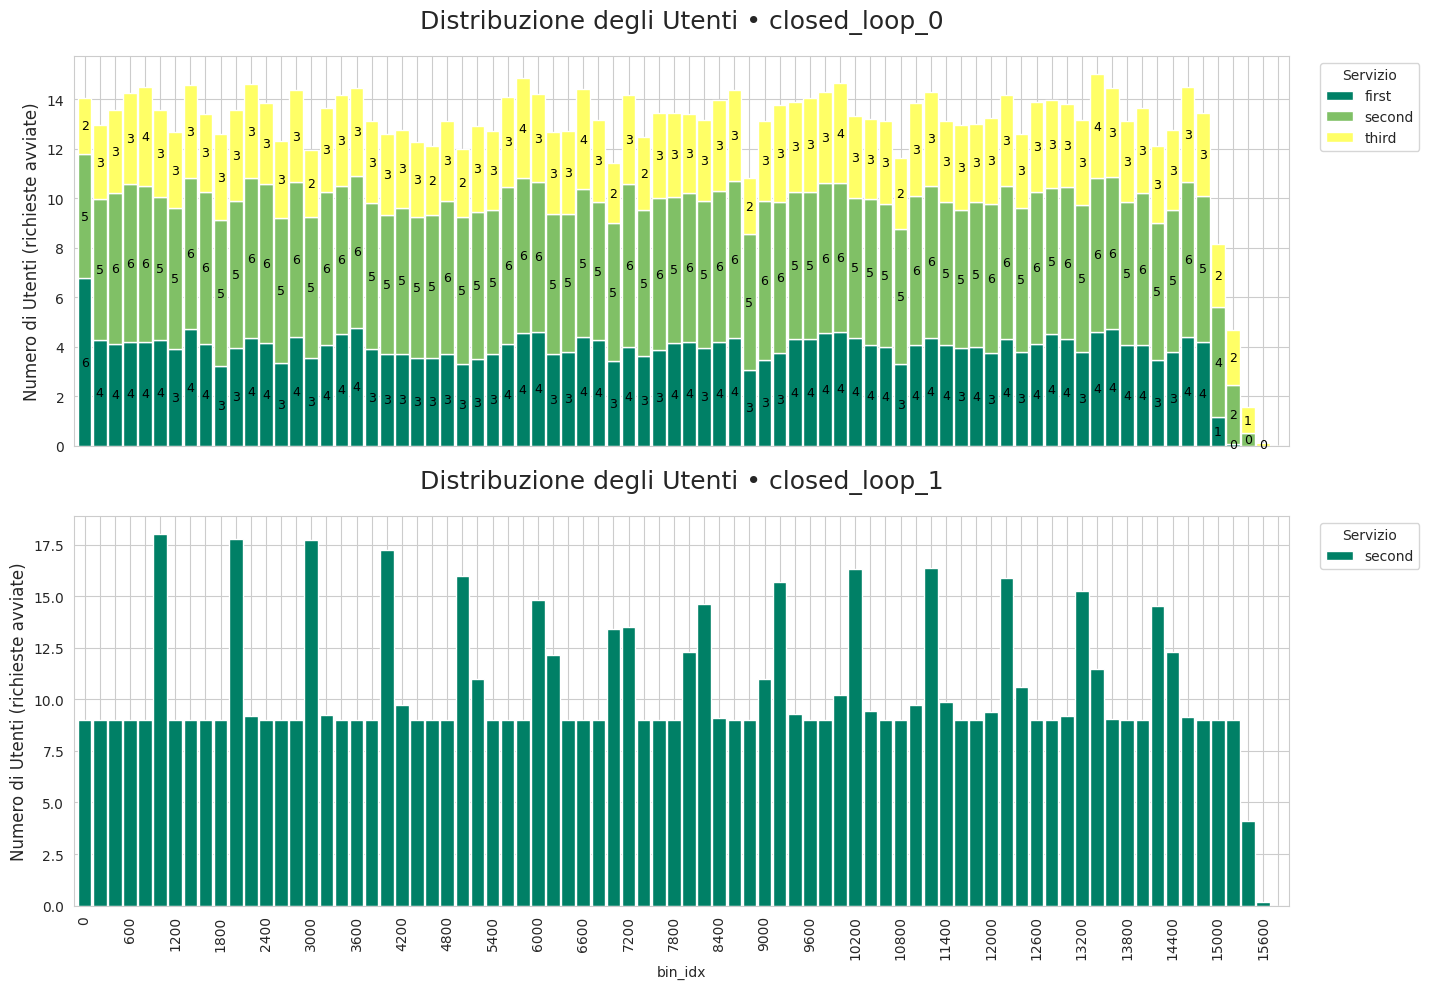

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from matplotlib.ticker import MultipleLocator

def parse_service_name(extra_tags_str: str) -> str:
    """
    Estrae il valore di 'service_name' dalla stringa extra_tags.
    Esempio: 'service_name=first,trace_id=...' -> 'first'
    """
    try:
        # Divide la stringa in base alle virgole e cerca il pezzo con 'service_name'
        for part in extra_tags_str.split(','):
            if 'service_name=' in part:
                return part.split('=')[1]
    except (TypeError, AttributeError):
        # Ritorna 'sconosciuto' se il campo è vuoto o non è una stringa
        return 'sconosciuto'
    return 'sconosciuto'

def create_user_load_plot(all_data: pd.DataFrame, time_step_ms: int = 500):
    """
    Carica i dati da una lista di file CSV, li elabora e crea un grafico
    a barre sovrapposte del carico di utenti nel tempo.

    Args:
        csv_files (list): Una lista di percorsi ai file CSV da analizzare.
        time_step_ms (int): L'ampiezza dell'intervallo di tempo in millisecondi.
    """
    requests_df = all_data.copy()

    if requests_df.empty:
        print("Non sono state trovate metriche 'http_reqs' nei file. Impossibile generare il grafico.")
        return

    bin_width_us = time_step_ms * 1000

    requests_df['service'] = requests_df['extra_tags'].apply(parse_service_name)
    requests_df['segment'] = requests_df['service'] + ' • ' + requests_df['scenario']
    requests_df['start_bin_idx'] = (requests_df['start_time_us'] // bin_width_us).astype(int)
    requests_df['end_bin_idx'] = (
        (np.maximum(requests_df['end_time_us'] - 1, requests_df['start_time_us'])) // bin_width_us
    ).astype(int)

    start_events = (
        requests_df.groupby(['iteration', 'segment', 'start_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        requests_df.groupby(['iteration', 'segment', 'end_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'], columns='segment', values='delta', aggfunc='sum', fill_value=0)

    min_bin = int(requests_df['start_bin_idx'].min())
    max_bin = int(requests_df['end_bin_idx'].max()) + 1
    iterations = sorted(requests_df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)], names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return
    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms

    column_tuples = []
    for seg in mean_user_counts.columns:
        parts = seg.split(' • ', 1)
        if len(parts) == 2:
            service, scenario = parts
        else:
            service, scenario = seg, 'sconosciuto'
        column_tuples.append((scenario.strip(), service.strip()))
    mean_user_counts.columns = pd.MultiIndex.from_tuples(column_tuples, names=['scenario', 'service'])

    scenarios = list(mean_user_counts.columns.levels[0])
    scenario_totals = mean_user_counts.groupby(level='scenario', axis=1).sum()

    sns.set_style("whitegrid")
    num_plots = len(scenarios)
    fig, axes = plt.subplots(num_plots, 1, figsize=(16, 6 * num_plots), sharex=True)
    if num_plots == 1:
        axes = [axes]

    def handle_x_ticks(ax, stacked=True):
        num_ticks = len(ax.get_xticklabels())
        if num_ticks > 50:
            tick_spacing = max(1, num_ticks // 25)
            for i, label in enumerate(ax.get_xticklabels()):
                if i % tick_spacing != 0:
                    label.set_visible(False)
        elif stacked:
            for container in ax.containers:
                labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
                ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

    for idx, scenario in enumerate(scenarios):
        ax = axes[idx]
        scenario_data = mean_user_counts.xs(scenario, axis=1)
        scenario_data.plot(
            kind='bar',
            stacked=True,
            figsize=(16, 10),
            width=0.9,
            ax=ax,
            colormap='summer'
        )
        ax.set_title(f"Distribuzione degli Utenti • {scenario}", fontsize=18, pad=20)
        ax.set_ylabel('Numero di Utenti (richieste avviate)', fontsize=12)
        ax.legend(title='Servizio', bbox_to_anchor=(1.02, 1), loc='upper left')
        handle_x_ticks(ax, stacked=True)
        if idx < num_plots - 1:
            ax.tick_params(labelbottom=False)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

# --- Esecuzione dello script ---

# Se vuoi cercare tutti i file .csv in una cartella, usa questa riga invece:
# csv_file_list = glob.glob(os.path.join(path_to_csv_folder, "*.csv"))

# Chiama la funzione per creare il grafico
create_user_load_plot(test_result, 200)

In [88]:
# per ogni servizio di ogni scenario, calcola il tempo e2e teorico, dalla media dei dati
def compute_mean_service_time(all_data: pd.DataFrame) -> pd.DataFrame:
    """
    Calcola il tempo medio di servizio (metric_value) per ogni run, scenario e servizio.
    """
    if all_data.empty:
        print("DataFrame vuoto: impossibile calcolare i tempi medi di servizio.")
        return pd.DataFrame(columns=["iteration", "scenario", "service", "mean_service_time_ms"])

    df = all_data[["iteration", "scenario", "service_name", "service", "extra_tags", "metric_value"]].copy()
    df["metric_value"] = pd.to_numeric(df["metric_value"], errors="coerce")
    df.dropna(subset=["metric_value"], inplace=True)

    result = (
        df.groupby(["scenario", "service_name", "service"], dropna=False)["metric_value"]
        .mean()
        .reset_index()
        .rename(columns={"metric_value": "mean_service_time_ms"})
        .sort_values(["scenario", "service_name", "service"])
        .reset_index(drop=True)
    )

    return result

mean_service_times = compute_mean_service_time(test_result)
mean_service_times

,scenario,service_name,service,mean_service_time_ms
0,closed_loop_0,first,exponentialop,85.697989
1,closed_loop_0,second,exponentialop,226.177367
2,closed_loop_0,third,exponentialop,42.757075
3,closed_loop_1,second,deterministic,1026.056299


In [ ]:
# ora carichiamo i dati dalla cartella base di tutte le combinazioni di servizi utilizzate per predirre i nostri tempi
from options_utility import extract_unique_pairs

def load_single_performance_results(num_cores: list, mu: list, service: str, concurrent_users: int, iteration: int, path: str = None) -> pd.DataFrame | None:
    folder_path = path
    
    file_path = os.path.join(folder_path, "metrics.json")
    with open(file_path) as train_file:
        dict = json.load(train_file)

    df = pd.json_normalize(dict['metrics'])
    df['users'] = df['vus_max.values.max']
    df['iteration'] = iteration
    df['duration'] = df['http_req_duration.values.avg']
    df['service'] = service
    df['mu'] = mu[0]
    df['cores'] = num_cores[0]

    return df

def load_performance_results(combinations) -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()
    RESULT_FOLDER = 'base'
    
    for exp in combinations:
        service_type = exp['type']
        arg = exp['arg_values']
        path_incomplete = os.path.join(RESULT_FOLDER, service_type, "performance", f"{get_s([1])}_core", str(get_s(arg)), f"{str(1)}_users")
        if os.path.exists(path_incomplete):
            for iteration in os.listdir(path_incomplete):
                path = os.path.join(path_incomplete, str(iteration))
                df = pd.concat([df, load_single_performance_results([1], [arg], service_type, [1], iteration, path=path)], ignore_index=True)
        else:
            if service_type in ["deterministic"]:
                print("Check if the service name is correct.")
                data = {
                    'users': 1,
                    'iteration': 1,
                    'duration': arg[0],
                    'service': service_type,
                    'mu': arg[0],
                    'cores': 1
                }

                df = pd.concat([df, pd.DataFrame([data])], ignore_index=True)

    # remove the columns whose names contain the string 'contains' and 'type'
    df = df.loc[:,~df.columns.str.contains('contains|type')]
    df = df.groupby(['service', 'mu', 'cores', 'users']).agg({'duration': 'mean'}).reset_index()
    df['job_size'] = df['duration']

    return df.fillna(0)

#extract_unique_pairs(options["WORKFLOW"])
performance_result = load_performance_results(extract_unique_pairs(options["WORKFLOW"]))
performance_result

Check if the service name is correct.


,service,mu,cores,users,duration,job_size
0,deterministic,1000,1,1,1000.000000,1000.000000
1,exponentialop,25000000,1,1,46.022869,46.022869
2,exponentialop,50000000,1,1,84.691966,84.691966


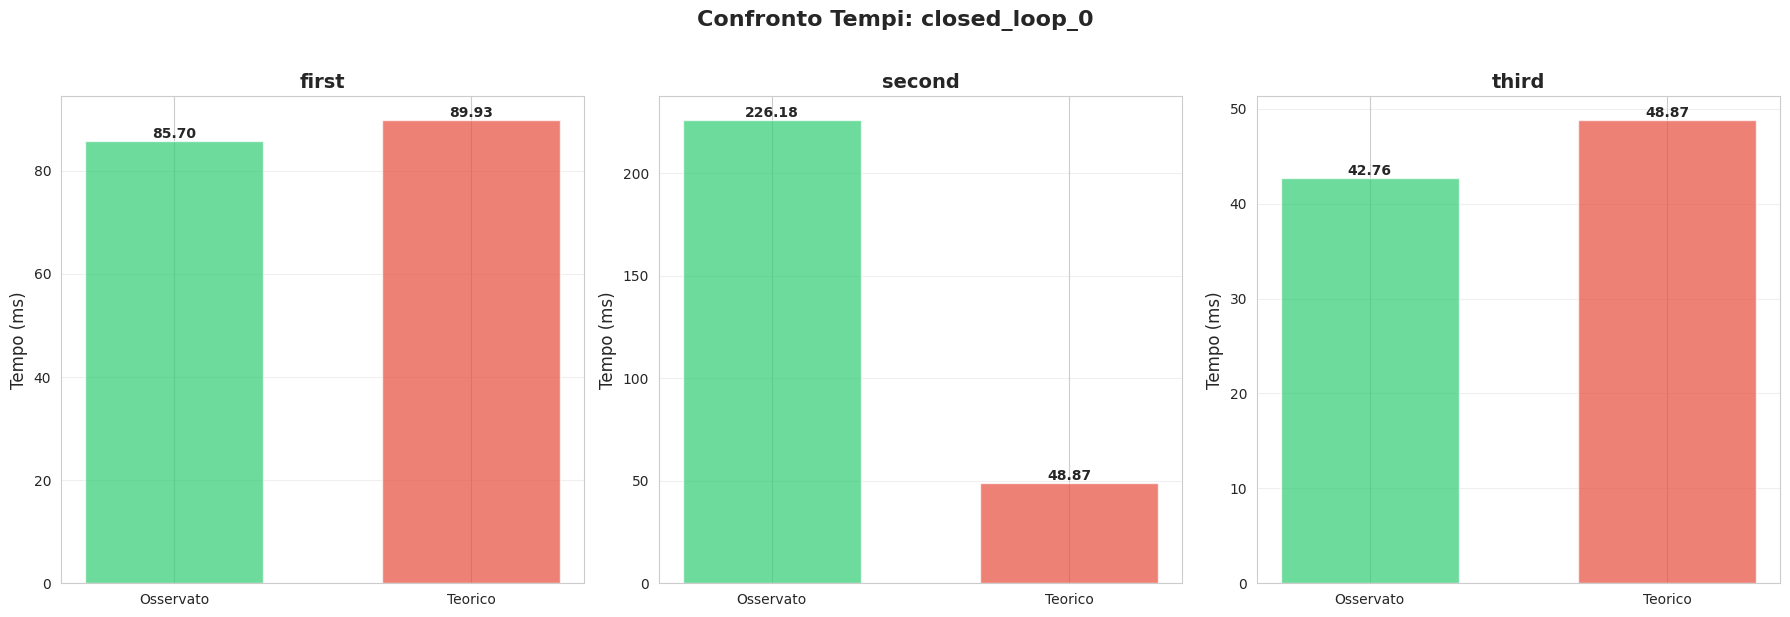

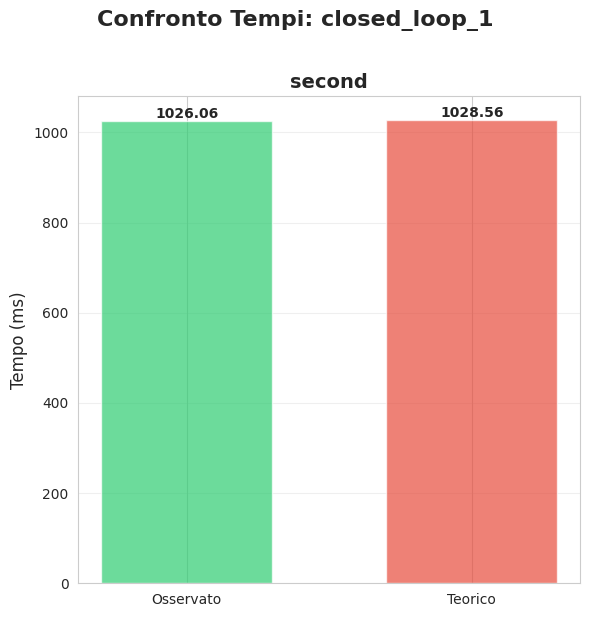

In [116]:
def create_user_load_prediction_plot(requests_df: pd.DataFrame, performance_data: pd.DataFrame, time_step_ms: int = 500):
    requests_df = requests_df.copy()

    bin_width_us = time_step_ms * 1000

    requests_df['segment'] = requests_df['service'] + ' • ' + requests_df['scenario']
    requests_df['start_bin_idx'] = (requests_df['start_time_us'] // bin_width_us).astype(int)
    requests_df['end_bin_idx'] = (
        (np.maximum(requests_df['end_time_us'] - 1, requests_df['start_time_us'])) // bin_width_us
    ).astype(int)

    # Calcola il numero di utenti concorrenti per ogni bin
    start_events = (
        requests_df.groupby(['iteration', 'segment', 'start_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        requests_df.groupby(['iteration', 'segment', 'end_bin_idx'])
        .size()
        .rename('delta')
        .reset_index()
        .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'], columns='segment', values='delta', aggfunc='sum', fill_value=0)

    min_bin = int(requests_df['start_bin_idx'].min())
    max_bin = int(requests_df['end_bin_idx'].max()) + 1
    iterations = sorted(requests_df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)], names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return
    
    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms

    column_tuples = []
    for seg in mean_user_counts.columns:
        parts = seg.split(' • ', 1)
        if len(parts) == 2:
            service, scenario = parts
        else:
            service, scenario = seg, 'sconosciuto'
        column_tuples.append((scenario.strip(), service.strip()))
    mean_user_counts.columns = pd.MultiIndex.from_tuples(column_tuples, names=['scenario', 'service'])

    # Calcola i tempi osservati medi per scenario e servizio
    observed_times = (
        requests_df.groupby(['scenario', 'service', 'service_name', 'mu', 'lambda'])['metric_value']
        .mean()
        .reset_index()
        .rename(columns={'metric_value': 'observed_time_ms'})
    )

    # Calcola i tempi teorici usando la formula di check_law
    theoretical_times = []
    for _, row in observed_times.iterrows():
        scenario = row['scenario']
        service = row['service']
        service_name = row['service_name']
        
        # Ottieni il job_size dal performance_data
        perf_match = performance_data[
            (performance_data['service'] == service) &
            (performance_data['mu'] == row['lambda']) & 
            (performance_data['users'] == 1) &
            (performance_data['cores'] == 1)
        ]
        
        if not perf_match.empty:
            job_size = perf_match['job_size'].values[0]
            
            # Ottieni cores e mu dal test_result
            test_match = requests_df[
                (requests_df['scenario'] == scenario) & 
                (requests_df['service'] == service) & 
                (requests_df['service_name'] == service_name)
            ]
            
            if not test_match.empty:
                cores = test_match['cores'].iloc[0] * 16
                l = test_match['lambda'].iloc[0]
                
                # Calcola il numero medio di utenti concorrenti per questo scenario/servizio
                segment_key = (scenario, service)
                if segment_key in mean_user_counts.columns:
                    avg_concurrent_users = mean_user_counts[segment_key].mean()
                    
                    # Calcola il tempo teorico: T = L * X / min(cores, L)
                    theoretical_time = avg_concurrent_users * job_size / np.minimum(cores, np.floor(avg_concurrent_users))
                    
                    theoretical_times.append({
                        'scenario': scenario,
                        'service_name': service_name,
                        'service': service,
                        'lambda': l,
                        'theoretical_time_ms': theoretical_time,
                        'cores': cores,
                        'concurrent_users': avg_concurrent_users
                    })

    theoretical_df = pd.DataFrame(theoretical_times)
    
    # Merge observed and theoretical times
    comparison_df = observed_times.merge(theoretical_df, on=['scenario', 'service', 'service_name', 'lambda'], how='left')

    # Crea i grafici
    scenarios = sorted(requests_df['scenario'].unique())

    for scenario in scenarios:
        scenario_comparison = comparison_df[comparison_df['scenario'] == scenario]

        if scenario_comparison.empty:
            continue

        services = scenario_comparison['service_name'].unique()
        num_services = len(services)

        fig, axes = plt.subplots(1, num_services, figsize=(6 * num_services, 6))
        if num_services == 1:
            axes = [axes]

        for idx, service_name in enumerate(services):
            ax = axes[idx]
            service_data = scenario_comparison[scenario_comparison['service_name'] == service_name]

            if service_data.empty:
                continue

            x = np.arange(2)
            observed = service_data['observed_time_ms'].values[0]
            theoretical = service_data['theoretical_time_ms'].values[0] if not pd.isna(service_data['theoretical_time_ms'].values[0]) else 0

            bars = ax.bar(x, [observed, theoretical], color=['#2ecc71', '#e74c3c'], alpha=0.7, width=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(['Osservato', 'Teorico'])
            ax.set_ylabel('Tempo (ms)', fontsize=12)
            ax.set_title(f'{service_name}', fontsize=14, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

            # Aggiungi valori sopra le barre
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

        fig.suptitle(f'Confronto Tempi: {scenario}', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

create_user_load_prediction_plot(test_result, performance_result, 200)

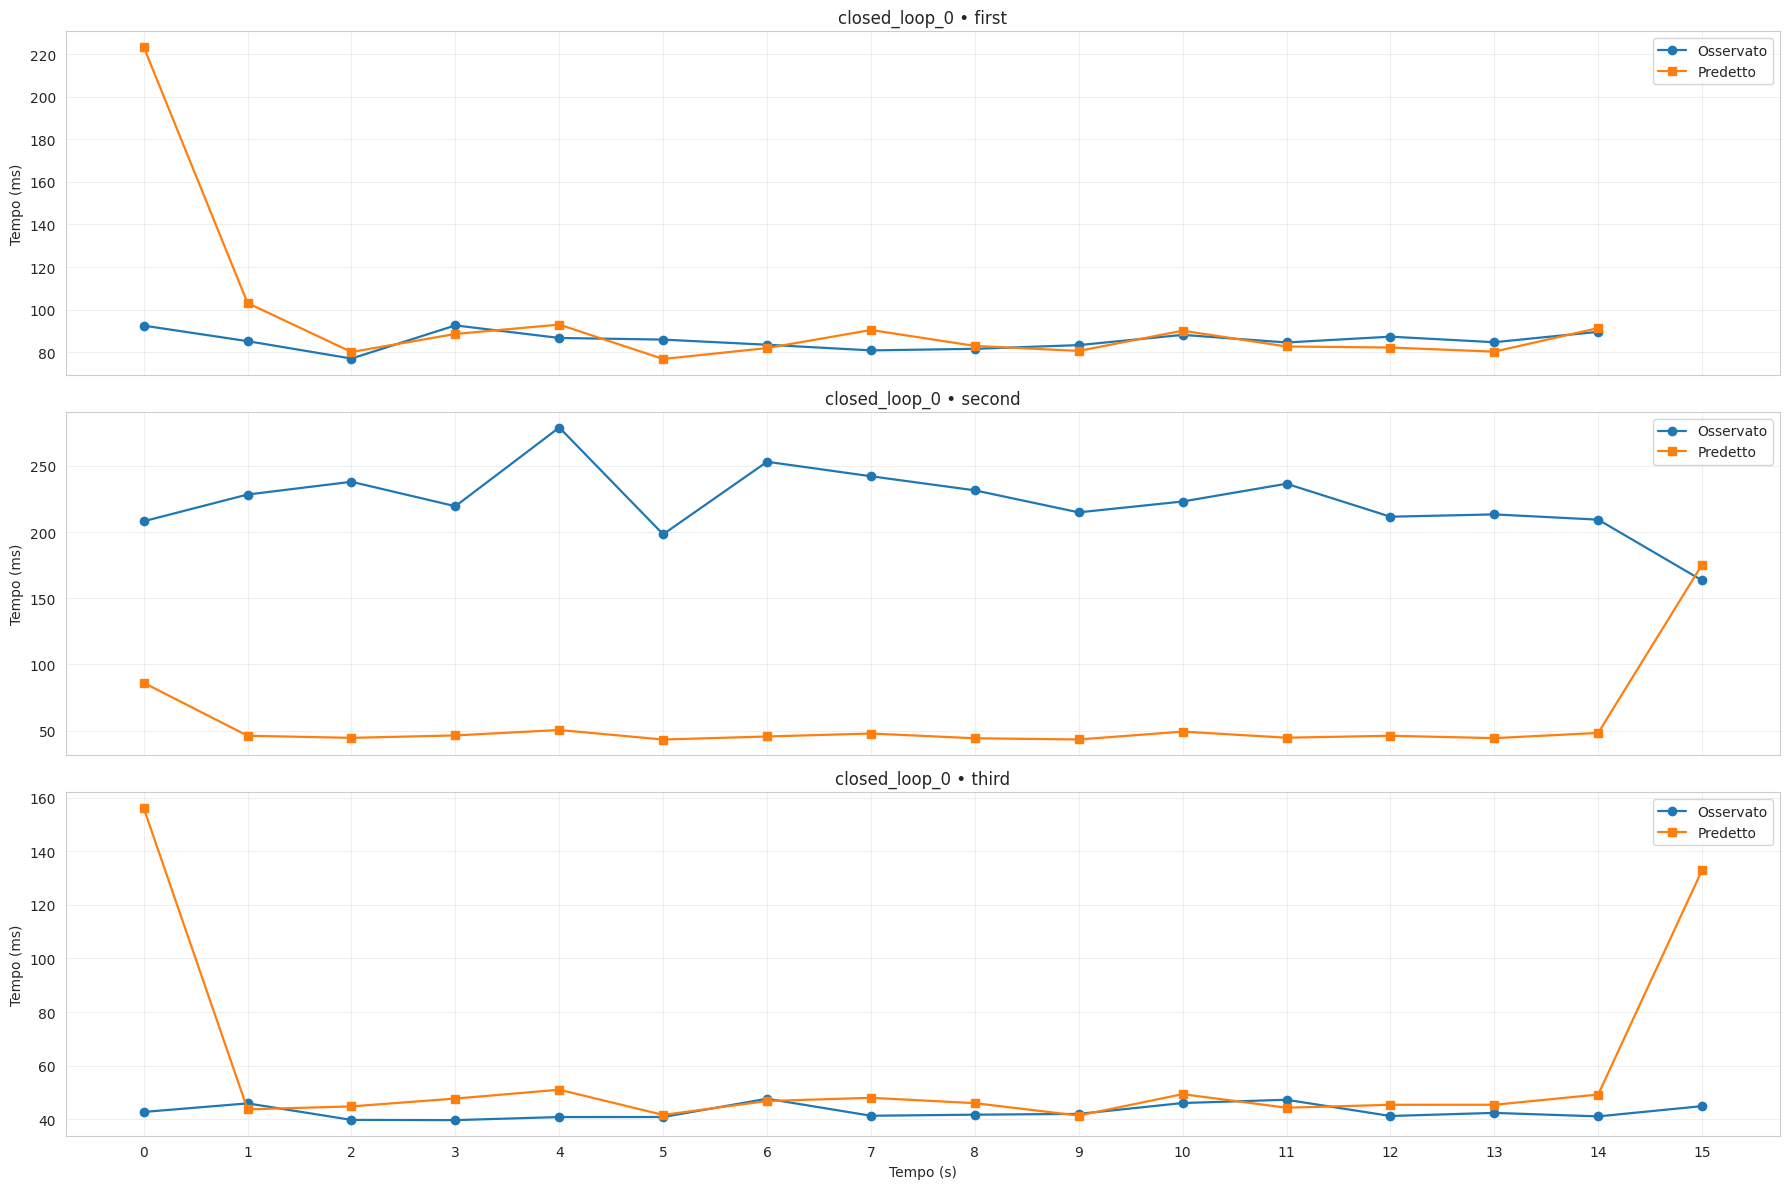

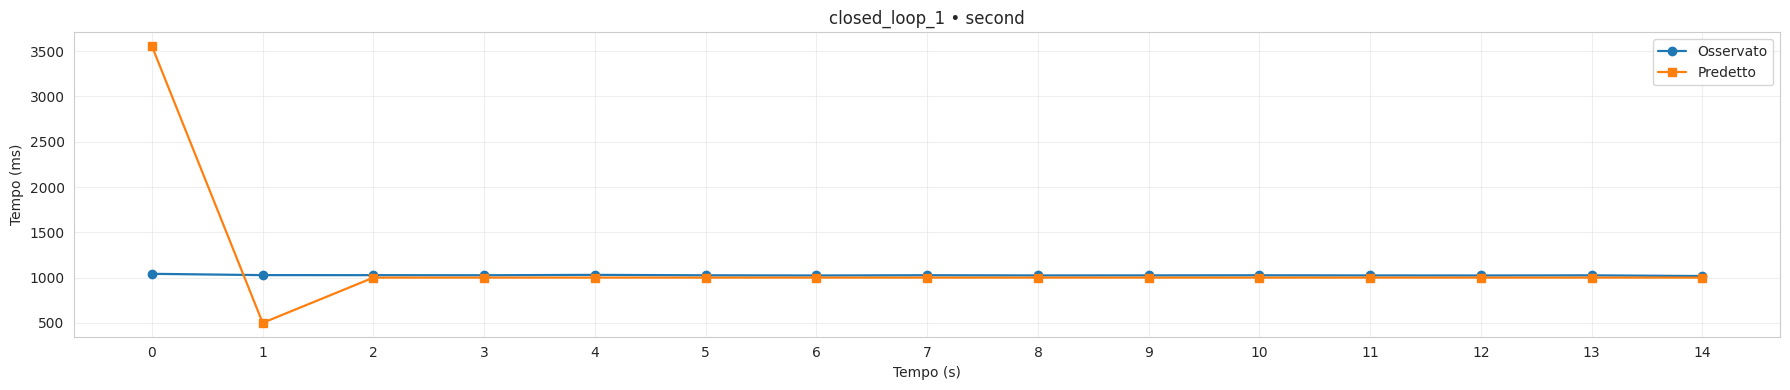

,time_ms,concurrent_users,service_name,scenario,time_s,service,mu,observed_time_ms,resources,users,duration,weight_ms,assigned_resources,previous_users,effective_resources,predicted_time_ms
0,0,18.20,first,closed_loop_0,0.0,exponentialop,50000000.0,92.523558,48,1.0,84.691966,84.691966,3,48.00,18.20,223.363426
4,1000,14.95,first,closed_loop_0,1.0,exponentialop,50000000.0,85.227853,48,1.0,84.691966,84.691966,3,18.20,14.95,103.103263
8,2000,15.80,first,closed_loop_0,2.0,exponentialop,50000000.0,77.063767,48,1.0,84.691966,84.691966,3,14.95,15.80,80.135752
12,3000,15.10,first,closed_loop_0,3.0,exponentialop,50000000.0,92.629780,48,1.0,84.691966,84.691966,3,15.80,15.10,88.618083
16,4000,13.75,first,closed_loop_0,4.0,exponentialop,50000000.0,86.736290,48,1.0,84.691966,84.691966,3,15.10,13.75,93.007177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,12000,18.00,second,closed_loop_1,12.0,deterministic,1000.0,1023.403908,32,1.0,1000.000000,1000.000000,2,18.00,18.00,1000.000000
54,13000,18.00,second,closed_loop_1,13.0,deterministic,1000.0,1024.951005,32,1.0,1000.000000,1000.000000,2,18.00,18.00,1000.000000
58,14000,18.00,second,closed_loop_1,14.0,deterministic,1000.0,1017.161426,32,1.0,1000.000000,1000.000000,2,18.00,18.00,1000.000000
62,15000,9.00,second,closed_loop_1,15.0,NaN,NaN,NaN,32,NaN,NaN,1000.000000,2,18.00,9.00,2000.000000


In [164]:
def create_user_load_prediction_comparison(requests_df: pd.DataFrame,
                                           theoretical_data: pd.DataFrame,
                                           time_step_ms: int = 1000) -> pd.DataFrame:
    """
    Confronta l'andamento osservato con una predizione basata sulla formula T = L·X / R,
    usando finestre di 1 secondo.
    """
    if requests_df.empty:
        print("DataFrame vuoto: impossibile generare il confronto.")
        return pd.DataFrame()

    if 'service_name' not in requests_df.columns:
        requests_df = requests_df.copy()
        requests_df['service_name'] = requests_df['extra_tags'].apply(parse_service_name)

    required_cols = {'scenario', 'service_name', 'metric_value', 'start_time_us', 'end_time_us'}
    if not required_cols.issubset(requests_df.columns):
        missing = required_cols - set(requests_df.columns)
        raise ValueError(f"Mancano colonne necessarie nel DataFrame richiesto: {missing}")

    weight_df = theoretical_data.copy()

    if 'weight_ms' not in weight_df.columns:
        for cand in ('job_size', 'duration', 'mean_service_time_ms'):
            if cand in weight_df.columns:
                weight_df = weight_df.rename(columns={cand: 'weight_ms'})
                break
        else:
            raise ValueError("Il DataFrame teorico deve fornire un peso in ms (es. 'job_size').")

    if 'resources' not in weight_df.columns:
        if 'cores' in weight_df.columns:
            weight_df = weight_df.rename(columns={'cores': 'resources'})
        else:
            weight_df['resources'] = 1

    bin_width_us = time_step_ms * 1000
    df = requests_df.copy()
    df['segment'] = df['service_name'] + ' • ' + df['scenario']
    df['start_bin_idx'] = (df['start_time_us'] // bin_width_us).astype(int)
    df['end_bin_idx'] = ((np.maximum(df['end_time_us'] - 1, df['start_time_us'])) // bin_width_us).astype(int)

    start_events = (
        df.groupby(['iteration', 'segment', 'start_bin_idx'])
          .size().rename('delta').reset_index()
          .rename(columns={'start_bin_idx': 'bin_idx'})
    )
    end_events = (
        df.groupby(['iteration', 'segment', 'end_bin_idx'])
          .size().rename('delta').reset_index()
          .rename(columns={'end_bin_idx': 'bin_idx'})
    )
    end_events['bin_idx'] += 1
    end_events['delta'] = -end_events['delta']

    events = pd.concat([start_events, end_events], ignore_index=True)
    events['bin_idx'] = events['bin_idx'].astype(int)
    changes = events.pivot_table(index=['iteration', 'bin_idx'],
                                 columns='segment',
                                 values='delta',
                                 aggfunc='sum',
                                 fill_value=0)

    min_bin = int(df['start_bin_idx'].min())
    max_bin = int(df['end_bin_idx'].max()) + 1
    iterations = sorted(df['iteration'].unique())
    full_index = pd.MultiIndex.from_product([iterations, range(min_bin, max_bin + 1)],
                                            names=['iteration', 'bin_idx'])
    changes = changes.reindex(full_index, fill_value=0)

    user_counts = changes.groupby(level='iteration').cumsum()
    mean_user_counts = user_counts.groupby(level='bin_idx').mean()
    if mean_user_counts.empty:
        print("Impossibile calcolare la media delle richieste attive.")
        return pd.DataFrame()

    mean_user_counts.index = mean_user_counts.index.astype(int) * time_step_ms
    concurrency = mean_user_counts.stack().reset_index()
    concurrency.columns = ['time_ms', 'scenario_service', 'concurrent_users']

    concurrency[['service_name', 'scenario']] = concurrency['scenario_service'].str.split(' • ', n=1, expand=True)
    concurrency.drop(columns='scenario_service', inplace=True)
    concurrency['time_s'] = concurrency['time_ms'] / 1000.0

    observed = (
        df.groupby(['scenario', 'service_name', 'service', 'lambda', 'start_bin_idx'])['metric_value']
          .mean().rename('observed_time_ms').reset_index()
    )
    observed['time_ms'] = observed['start_bin_idx'] * time_step_ms
    observed['time_s'] = observed['time_ms'] / 1000.0
    observed.drop(columns='start_bin_idx', inplace=True)

    resource_lookup = (
        df.groupby(['scenario', 'service_name'])['cores']
          .first().rename('assigned_resources').reset_index()
        if 'cores' in df.columns else pd.DataFrame()
    )

    merge_keys = ['service', 'mu']
    if 'scenario' in weight_df.columns:
        merge_keys.append('scenario')
    weight_df = weight_df[weight_df['weight_ms'] > 0]

    comparison = concurrency.merge(observed, on=['scenario', 'service_name', 'time_ms', 'time_s'], how='left')
    comparison.rename(columns={'lambda': 'mu'}, inplace=True)
    comparison = comparison.merge(weight_df, on=merge_keys, how='left')
    if not resource_lookup.empty:
        comparison = comparison.merge(resource_lookup, on=['scenario', 'service_name'], how='left')

    if 'assigned_resources' in comparison.columns:
        comparison['resources'] = comparison['assigned_resources'].fillna(1)
    else:
        comparison['resources'] = 1
    comparison['resources'] = comparison['resources'].replace(0, 1) * 16
    comparison['weight_ms'] = (
        comparison.groupby(['scenario', 'service_name'])['weight_ms']
                  .ffill()
                  .bfill()
    )
    comparison = comparison.sort_values(['scenario', 'service_name', 'time_ms'])
    comparison['previous_users'] = (
        comparison.groupby(['scenario', 'service_name'])['concurrent_users']
                  .shift(1)
    )
    comparison['previous_users'] = comparison['previous_users'].fillna(comparison['resources'])
    comparison['effective_resources'] = comparison[['resources', 'concurrent_users']].min(axis=1).replace(0, 1)
    comparison['predicted_time_ms'] = (comparison['previous_users'] * comparison['weight_ms']) / comparison['effective_resources']
    
    scenarios = sorted(comparison['scenario'].dropna().unique())
    for scenario in scenarios:
        scenario_df = comparison[comparison['scenario'] == scenario].dropna(subset=['observed_time_ms', 'predicted_time_ms'])
        if scenario_df.empty:
            continue

        services = sorted(scenario_df['service_name'].unique())
        fig, axes = plt.subplots(len(services), 1, figsize=(18, 4 * len(services)), sharex=True)
        if len(services) == 1:
            axes = [axes]

        for ax, service_name in zip(axes, services):
            service_df = scenario_df[scenario_df['service_name'] == service_name]
            ax.plot(service_df['time_s'], service_df['observed_time_ms'], label='Osservato', marker='o', linewidth=1.6)
            ax.plot(service_df['time_s'], service_df['predicted_time_ms'], label='Predetto', marker='s', linewidth=1.6)
            ax.set_title(f"{scenario} • {service_name}")
            ax.set_ylabel("Tempo (ms)")
            ax.grid(alpha=0.3)
            ax.set_xticks(service_df['time_s'])
            ax.legend()

        axes[-1].set_xlabel("Tempo (s)")
        plt.tight_layout()
        plt.show()

    return comparison

comparison_df = create_user_load_prediction_comparison(test_result, performance_result, time_step_ms=1000)
comparison_df